## Prognose des Tinnitus Zustandes

# Prognose

In [102]:
40/3

13.333333333333334

In [56]:
# Bibliotheken laden
import pandas as pd
from xgboost import XGBClassifier
from xgboost import plot_importance
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [93]:
# Daten laden
df = pd.read_csv('/Users/elias/Desktop/Uni/4. Semester : Masterarbeit/2026-04-27 df_event.csv')
df['time:timestamp'] = pd.to_datetime(df['time:timestamp'])

In [94]:
# Konvertiere concept:name / score in Zahlen, bevor das Modell trainiert wird
df['concept:name_encoded'] = df['concept:name'].astype('category').cat.codes

In [95]:
# Vorbereitung fürs Modell

# KONFIGURATION
WINDOW_SIZE = 10 # wie viele Einträge der Vergangenheit sollen beachtet werden? Die letzten X Einträge.
FEATURES_TO_LAG = ['q1', 'sound_norm', 'concept:name_encoded'] # Welche Spalten sollen in die Historie einfließen? Spalten einfach dazu- / wegnehmen.
TARGET_COL = 'q1'
USER_ID_COL = 'case:concept:name'
TIME_COL = 'time:timestamp'


# Erstellt für jeden User die letzten N Schritte als Features.
def create_lagged_features(df, window_size, features_to_lag, user_col, time_col):

    # Daten sortieren
    df = df.sort_values([user_col, time_col])
    df_result = df.copy()

    # Schleife über die in FEATURES_TO_LAG definierten Spalten
    for feature in features_to_lag:
        for i in range(1, window_size + 1):
            # Erstellt z.B. 'q1_lag1', 'sound_norm_lag1', 'score_lag1' usw.
            df_result[f'{feature}_lag{i}'] = df.groupby(user_col)[feature].shift(i)

    # Entfernen der Zeilen mit unvollständiger Historie
    df_result = df_result.dropna()

    return df_result


df_prepared = create_lagged_features(df, WINDOW_SIZE, FEATURES_TO_LAG, USER_ID_COL, TIME_COL)

In [96]:
# Teilt die Daten so, dass der letzte Eintrag jedes Users im Testset landet und der Rest im Training.
def split_by_last_event(df, user_col, time_col):

    # Sortieren
    df = df.sort_values([user_col, time_col])

    # Den letzten Eintrag pro User markieren
    last_indices = df.groupby(user_col).tail(1).index

    # Splitten
    test_df = df.loc[last_indices]
    train_df = df.drop(last_indices)

    return train_df, test_df

In [97]:
# Train Test Split

# Split in Training und Test
train_df, test_df = split_by_last_event(df_prepared, USER_ID_COL, TIME_COL)

# Features und Ziel definieren
# Alle Spalten, die 'lag' im Namen haben, sind unsere Input-Features
feature_cols = [col for col in df_prepared.columns if 'lag' in col]

X_train = train_df[feature_cols]
y_train = train_df[TARGET_COL]

X_test = test_df[feature_cols]
y_test = test_df[TARGET_COL]

print(f"Trainingsdaten: {X_train.shape[0]} Zeilen")
print(f"Testdaten: {X_test.shape[0]} Zeilen")

Trainingsdaten: 82268 Zeilen
Testdaten: 919 Zeilen


In [99]:
# Modell trainieren V1

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Initialisierung
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    eval_metric='logloss'
)

# Training
model.fit(X_train, y_train)

# Vorhersage auf dem Testset
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1] # Wahrscheinlichkeiten für Klasse 1

# Evaluation
print("Klassifikationsbericht:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

Klassifikationsbericht:
              precision    recall  f1-score   support

         0.0       0.69      0.70      0.69       179
         1.0       0.93      0.92      0.93       740

    accuracy                           0.88       919
   macro avg       0.81      0.81      0.81       919
weighted avg       0.88      0.88      0.88       919

ROC-AUC Score: 0.8987


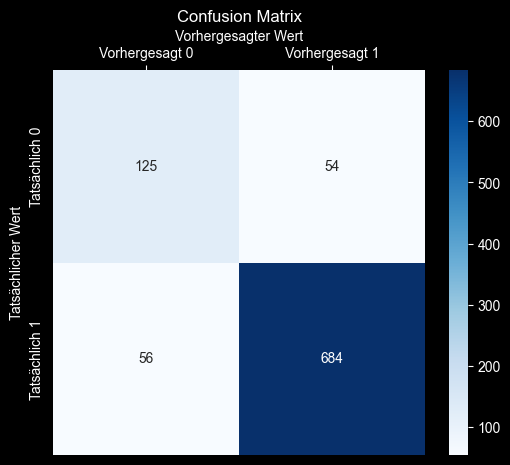

In [100]:
# Confusion Matrix ausgeben

# Matrix berechnen
cm = confusion_matrix(y_test, y_pred)

# Heatmap erstellen
plt.figure(figsize=(6, 5))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Vorhergesagt 0', 'Vorhergesagt 1'],
            yticklabels=['Tatsächlich 0', 'Tatsächlich 1'])

# Label und Ticks nach oben
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()

plt.ylabel('Tatsächlicher Wert')
plt.xlabel('Vorhergesagter Wert')
plt.title('Confusion Matrix')
plt.show()

In [38]:
''' -> je nach Modell kommen andere Feature Importances raus
# Modell trainieren V2 (mit scale_pos_weight)
# scale_pos_weight hilft, falls die Klassen (Tinnitus vs. kein Tinnitus) ungleich verteilt sind

# Berechnet das Verhältnis von 0 zu 1 von q1 für XGBoost.
def get_class_weights(y):
    count_0 = (y == 0).sum()
    count_1 = (y == 1).sum()

    print(f"Verteilung der Daten: Klasse 0 = {count_0}, Klasse 1 = {count_1}")

    # scale_pos_weight = count_neg / count_pos
    weight = count_0 / count_1
    print(f"Berechnetes scale_pos_weight für XGBoost: {weight:.4f}")

    return weight


from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Gewichtung berechnen
scale_pos = get_class_weights(y_train)

# Modell mit Gewichtung initialisieren
model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    scale_pos_weight=scale_pos, # Hier wird die Gewichtung angewendet
    eval_metric='logloss'
)

model.fit(X_train, y_train)

# Evaluation
from sklearn.metrics import f1_score, roc_auc_score
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Loggen

experiment_logs = []
def log_experiment(params, metrics):
    log_entry = {'params': params, 'metrics': metrics}
    experiment_logs.append(log_entry)


log_experiment(
    params={'window_size': 10, 'max_depth': 5},
    metrics={
        'auc': roc_auc_score(y_test, y_proba),
        'f1': f1_score(y_test, y_pred)
    }
)
'''

Verteilung der Daten: Klasse 0 = 14792, Klasse 1 = 68920
Berechnetes scale_pos_weight für XGBoost: 0.2146

Klassifikationsbericht:
              precision    recall  f1-score   support

         0.0       0.45      0.90      0.59       182
         1.0       0.97      0.73      0.83       750

    accuracy                           0.76       932
   macro avg       0.71      0.81      0.71       932
weighted avg       0.86      0.76      0.79       932

ROC-AUC Score: 0.9036


In [ ]:
'''
# zu: Modell trainieren V2

print(f"\nKlassifikationsbericht:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")
'''

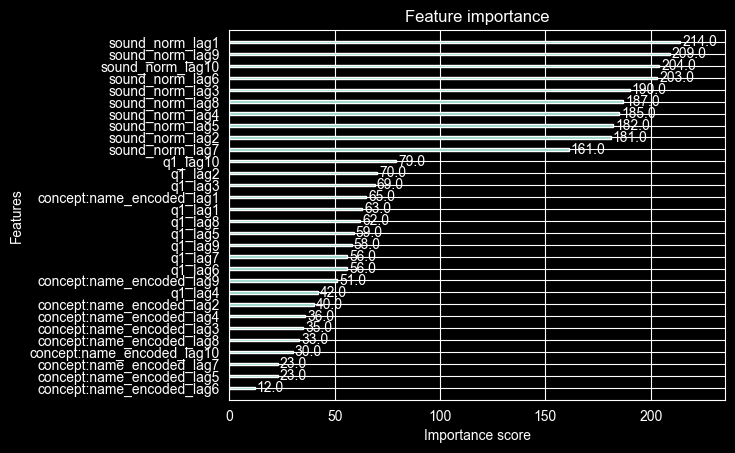

In [101]:
# schauen, was XGBoost genau gemacht hat
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(model, max_num_features=30)
plt.show()

In [ ]:
# lag1 ist der letzte Eintrag vor dem zu Prognostizierenden. lag10 ist der 10. Eintrag vor dem zu Prognostizierenden.
# je größer "Importance Score", desto wichtiger ist dieser Wert für die Prognose.